## Transforms

In [2]:
from torchvision import transforms
# test transform
test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

## Model builder

In [3]:
import torch.nn as nn
import torchvision.models as models


def freeze_all(model):
    for p in model.parameters():
        p.requires_grad = False


def unfreeze_all(model):
    for p in model.parameters():
        p.requires_grad = True


def get_model(cfg):

    if cfg.architecture == "resnet":

        model = models.resnet34(weights="DEFAULT")
        in_feats = model.fc.in_features

        model.fc = nn.Sequential(
            nn.Linear(in_feats, cfg.hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(cfg.hidden_dim, cfg.num_classes)
        )

    elif cfg.architecture == "vgg":

        model = models.vgg16(weights="DEFAULT")
        in_feats = model.classifier[-1].in_features

        model.classifier[-1] = nn.Sequential(
            nn.Linear(in_feats, cfg.hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(cfg.hidden_dim, cfg.num_classes)
        )

    else:
        raise ValueError("Unsupported architecture")

    # training regime
    if cfg.training_mode == "fixed":

        freeze_all(model)

        # classifier must stay trainable
        if cfg.architecture == "resnet":
            for p in model.fc.parameters():
                p.requires_grad = True
        else:
            for p in model.classifier[-1].parameters():
                p.requires_grad = True

    elif cfg.training_mode == "full":

        unfreeze_all(model)

    elif cfg.training_mode == "progressive":

        freeze_all(model)

        if cfg.architecture == "resnet":
            for p in model.fc.parameters():
                p.requires_grad = True
        else:
            for p in model.classifier[-1].parameters():
                p.requires_grad = True

    else:
        raise ValueError("Unknown training mode")

    return model.to(cfg.device)

In [4]:
# Path to dataset and initialize pytorch Imagefolder
import os
from torchvision.datasets import ImageFolder

image_paths = '/home/adjalil/Working/data_lionel/data_patch'
data = ImageFolder(root=image_paths, transform=test_transform)

test_dataset  = ImageFolder(os.path.join(image_paths, "test"), transform=test_transform)

print("Classes:", test_dataset.classes)
print("Classes:", test_dataset.class_to_idx)
print("Total images:", len(data))

Classes: ['healthy', 'mildiou']
Classes: {'healthy': 0, 'mildiou': 1}
Total images: 6552


In [5]:
import torch
class Config:
    architecture = "resnet"          # "resnet" | "vgg"
    training_mode = "fixed"          # "fixed" | "progressive" | "full"

    num_classes = 2
    hidden_dim = 512

    batch_size = 16
    lr = 1e-3
    epochs = 15
    prg_finetune_epoch = 3
    patience_earlystop = 3

    device = "cuda" if torch.cuda.is_available() else "cpu"

cfg = Config()

/home/adjalil/miniforge3/envs/fdeepl/lib/python3.10/site-packages/torch/cuda/__init__.py:129: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0


## Test: Make prediction

/tmp/ipykernel_57216/4033751570.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(f"{cfg.training_mode}_best_model.pth", map_location=cfg.device)
Clipping input

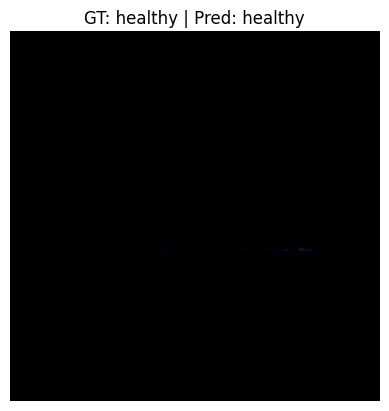

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6155462..2.5179958].


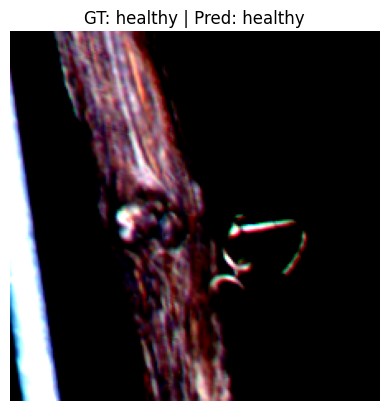

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4842881..-0.13143253].


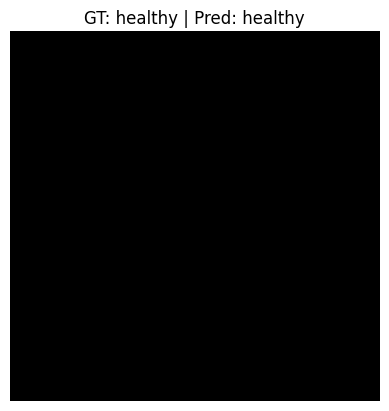

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9481792..0.9816765].


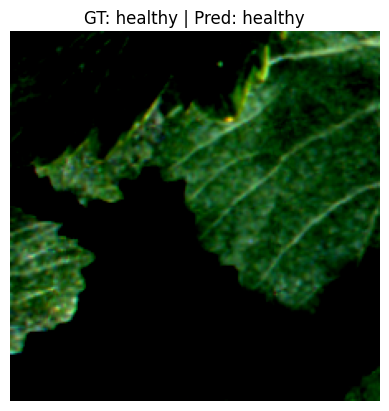

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6384109..2.3585434].


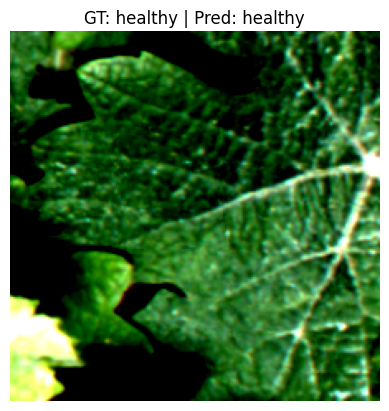

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4404761..0.878928].


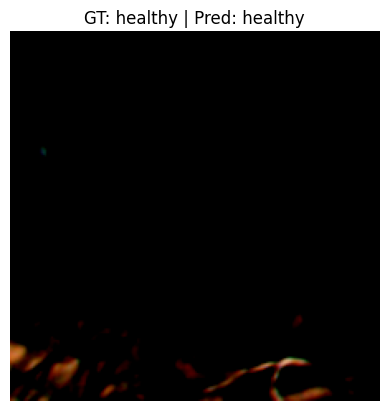

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7240347..1.6666666].


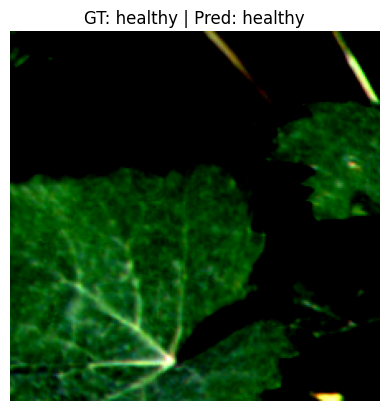

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7582842..2.2710083].


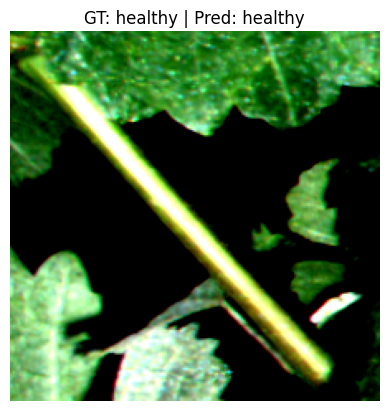

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5870366..1.6057423].


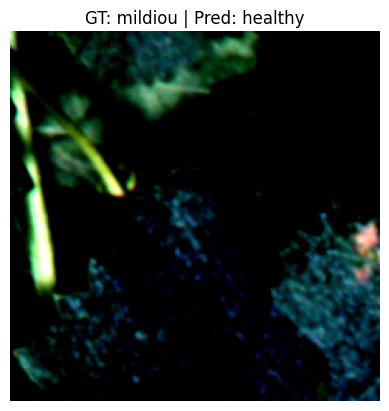

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8781574..1.7511113].


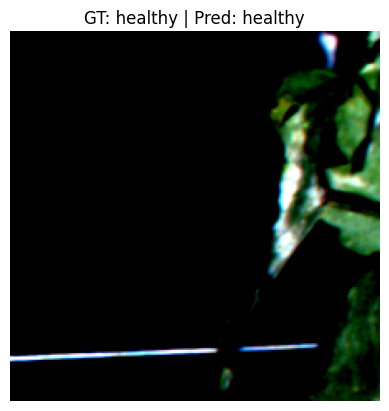

In [6]:
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Prediction loop (first 10 images)

model = get_model(cfg)
model.load_state_dict(
    torch.load(f"{cfg.training_mode}_best_model.pth", map_location=cfg.device)
)

model.to(cfg.device)
model.eval()



test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=True
)



class_names = test_dataset.classes
n_images = 10
count = 0

with torch.no_grad():

    for imgs, labels in test_loader:

        imgs = imgs.to(cfg.device)
        labels = labels.to(cfg.device)

        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)

        img = imgs.cpu().squeeze().permute(1,2,0)

        plt.imshow(img)
        plt.title(
            f"GT: {class_names[labels.item()]} | "
            f"Pred: {class_names[preds.item()]}"
        )
        plt.axis("off")
        plt.show()

        count += 1
        if count == n_images:
            break

### Overlay disease patches to ensure model prediction is correct

In [7]:
import os
import cv2
import glob
from PIL import Image

test_root = "/home/adjalil/Working/data_lionel/data_split/test/raw"
output_dir = "./results/test_predictions"

# mean = torch.tensor([0.485, 0.456, 0.406])
# std  = torch.tensor([0.229, 0.224, 0.225])

# img = img * std + mean
# img = img.clamp(0,1)

PATCH_SIZE = 224
BATCH_SIZE = 64


transform = transforms.Compose([
    transforms.Resize((PATCH_SIZE, PATCH_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

device = "cuda" if torch.cuda.is_available() else "cpu"


for class_name in os.listdir(test_root):
    # print(class_name)
    # break
    os.makedirs(os.path.join(output_dir, class_name), exist_ok=True)

    class_dir = os.path.join(test_root, class_name)

    for image_path in glob.glob(os.path.join(class_dir, "*.tif")):

        # output name
        image_name = os.path.basename(image_path)
        image_out = os.path.join(output_dir, class_name, image_name)

        # -----------------------------
        # READ IMAGE
        # -----------------------------
        img = cv2.imread(image_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        H, W, _ = img.shape
        result_img = img.copy()

        patches = []
        coords = []

        # -----------------------------
        # PATCH EXTRACTION
        # -----------------------------
        for y in range(0, H, PATCH_SIZE):
            for x in range(0, W, PATCH_SIZE):

                patch = img[y:y+PATCH_SIZE, x:x+PATCH_SIZE]

                if patch.shape[0] != PATCH_SIZE or patch.shape[1] != PATCH_SIZE:
                    continue

                patch_pil = Image.fromarray(patch)
                tensor = transform(patch_pil)

                patches.append(tensor)
                coords.append((x, y))

        if len(patches) == 0:
            continue

        patches = torch.stack(patches)

        # -----------------------------
        # INFERENCE
        # -----------------------------
        predictions = []

        with torch.no_grad():
            for i in range(0, len(patches), BATCH_SIZE):
                batch = patches[i:i+BATCH_SIZE].to(device)
                logits = model(batch)
                preds = torch.argmax(logits, dim=1)
                predictions.extend(preds.cpu().numpy())

        # -----------------------------
        # OVERLAY DISEASE PATCHES
        # -----------------------------
        for (x, y), pred in zip(coords, predictions):

            if pred == 1:
                overlay = result_img.copy()
                cv2.rectangle(
                    overlay,
                    (x, y),
                    (x + PATCH_SIZE, y + PATCH_SIZE),
                    (255, 0, 0),
                    -1
                )

                alpha = 0.4
                result_img = cv2.addWeighted(
                    overlay,
                    alpha,
                    result_img,
                    1 - alpha,
                    0
                )

        # -----------------------------
        # SAVE RESULT
        # -----------------------------
        result_img = cv2.cvtColor(result_img, cv2.COLOR_RGB2BGR)
        cv2.imwrite(image_out, result_img)
        print("saved:", image_out)

saved: ./results/test_predictions/healthy/uplot_2020002_1_camera_2_9_RGB_WB_V_U_1719302719.tif
saved: ./results/test_predictions/healthy/uplot_2001001_1_camera_2_4_RGB_WB_V_U_1750660102.tif
saved: ./results/test_predictions/healthy/uplot_2014001_1_camera_2_8_RGB_WB_V_U_1721726900.tif
saved: ./results/test_predictions/mildiou/uplot_2001001_1_camera_1_1_RGB_WB_V_U_1724304788.tif
saved: ./results/test_predictions/mildiou/uplot_2001001_1_camera_1_7_RGB_WB_V_U_1723100019.tif


## Simple GradCAM (Resnet18)

In [8]:
import cv2
import numpy as np

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer

        self.gradients = None
        self.activations = None

        self.forward_handle = target_layer.register_forward_hook(
            self.save_activation
        )

        self.backward_handle = target_layer.register_full_backward_hook(
            self.save_gradient
        )

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, input_image, class_idx=None):
        self.model.zero_grad()

        output = self.model(input_image)

        if class_idx is None:
            class_idx = torch.argmax(output, dim=1).item()

        loss = output[:, class_idx]
        loss.backward()

        gradients = self.gradients[0]
        activations = self.activations[0]

        weights = torch.mean(gradients, dim=(1,2))
        cam = torch.zeros(activations.shape[1:], device=activations.device)

        for i, w in enumerate(weights):
            cam += w * activations[i]

        cam = torch.relu(cam)
        cam = cam / (cam.max() + 1e-8)

        return cam.detach().cpu().numpy()

    def remove_hooks(self):
        self.forward_handle.remove()
        self.backward_handle.remove()

In [9]:
def show_gradcam(image_path, model, transform, device):

    model.eval()

    image = Image.open(image_path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0).to(device)

    target_layer = model.layer4[-1]

    for param in model.parameters():
        param.requires_grad = True
    
    model.eval()

    gradcam = GradCAM(model, target_layer)
    cam = gradcam.generate(input_tensor)

    gradcam.remove_hooks()  # IMPORTANT

    img = np.array(image.resize((224,224)))
    heatmap = cv2.resize(cam, (224,224))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed = heatmap * 0.4 + img
    superimposed = np.uint8(superimposed)

    plt.figure()
    plt.imshow(superimposed)
    plt.axis("off")
    plt.show()

for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)

fc.0.weight
fc.0.bias
fc.3.weight
fc.3.bias


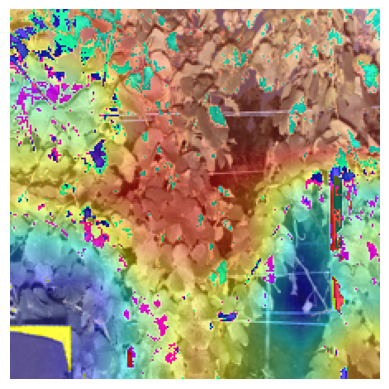

In [10]:
show_gradcam(
    image_path="/home/adjalil/Working/data_lionel/data_split/test/raw/mildiou/uplot_2001001_1_camera_1_1_RGB_WB_V_U_1724304788.tif",
    model=model,
    transform=test_transform,
    device=cfg.device
)